#  Inference-Time Scaling Via Self-Refinement

#### Loading model and tokenizer

In [1]:
import pathlib
import torch
import sympy
import tokenizers

In [2]:
device = torch.device("gpu" if torch.cuda.is_available() else "cpu")

In [3]:
from utils import load_model_tokenizer
model, tokenizer = load_model_tokenizer("base", device)

In [4]:
from utils import render_prompt
from reasoning_from_scratch.ch04 import (generate_text_stream_concat_flex, generate_text_top_p_stream_cache)

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)
prompt_cot = prompt + "\n\nExplain step by step."

torch.manual_seed(123)
response_1 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9
)

torch.manual_seed(42)
response_2 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9
)

 We begin with the equation that represents the given condition:
$$\frac{1}{2}(3x - 9) = x + 37$$

**Step 1:** Distribute $\frac{1}{2}$ to both terms inside the parentheses:
$$\frac{1}{2}(3x) - \frac{1}{2}(9) = x + 37$$

**Step 2:** Simplify each term:
$$\frac{3}{2}x - \frac{9}{2} = x + 37$$

**Step 3:** Subtract $x$ from both sides to get all $x$-terms on one side:
$$\frac{3}{2}x - x - \frac{9}{2} = 37$$

**Step 4:** Simplify the $x$-terms:
$$\frac{1}{2}x - \frac{9}{2} = 37$$

**Step 5:** Add $\frac{9}{2}$ to both sides to isolate the $x$-term:
$$\frac{1}{2}x = 37 + \frac{9}{2}$$

**Step 6:** Convert $37$ to a fraction with a denominator of $2$:
$$\frac{1}{2}x = \frac{74}{2} + \frac{9}{2}$$

**Step 7:** Combine the fractions:
$$\frac{1}{2}x = \frac{83}{2}$$

**Step 8:** Multiply both sides by $2$ to solve for $x$:
$$2 \cdot \frac{1}{2}x = 2 \cdot \frac{83}{2}$$

**Step 9:** Simplify:
$$x = 83$$

Therefore, the value of $x$ is $\boxed{83}$. First, we need to set up the equation based o

In [5]:
print("Response 1 characters:", len(response_1))
print("Response 1 tokens:", len(tokenizer.encode(response_1)))
print("\nResponse 2 characters:", len(response_2))
print("Response 2 tokens:", len(tokenizer.encode(response_2)))

Response 1 characters: 954
Response 1 tokens: 408

Response 2 characters: 756
Response 2 tokens: 287


### Scoring LLM responses with a rule-based score

Use best score response in self consistency vote

In [4]:
from reasoning_from_scratch.ch03 import extract_final_candidate
import math

def heuristic_score(answer, brevity_bonus = 500.0,
                    boxed_bonus = 2.0, extract_bonus = 1.0, fulltext_bonus = 0.0) -> float:
    score = 0.0
    result = extract_final_candidate(answer, fallback="none")
    if result:
        score += boxed_bonus #reward boxed answer
    else:
        result = extract_final_candidate(answer,fallback= "number_only")
        if result:
            score += extract_bonus
        else:
            result = extract_final_candidate(answer, fallback="number_then_full")
            if result:
                score += fulltext_bonus
    
    score += 1.5*math.exp(-len(answer)/brevity_bonus) # rewards short answer (sees char length not token)
    return score


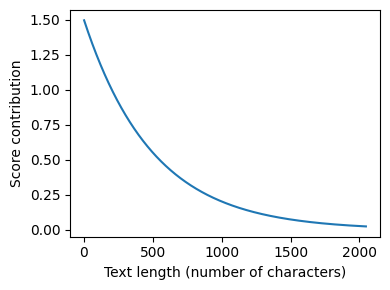

In [5]:
import matplotlib.pyplot as plt

def plot_brevity_curve(brevity_bonus, max_len=2048):
    lengths = torch.arange(1, max_len)
    scores = 1.5 * torch.exp(-lengths / brevity_bonus)

    plt.figure(figsize=(4, 3))
    plt.plot(lengths, scores)
    plt.xlabel("Text length (number of characters)")
    plt.ylabel("Score contribution")
    plt.tight_layout()
    plt.show()

plot_brevity_curve(500)

In [8]:
print(round(heuristic_score(response_1), 3))
print(round(heuristic_score(response_2), 3))

2.223
2.331


### Token probability scores

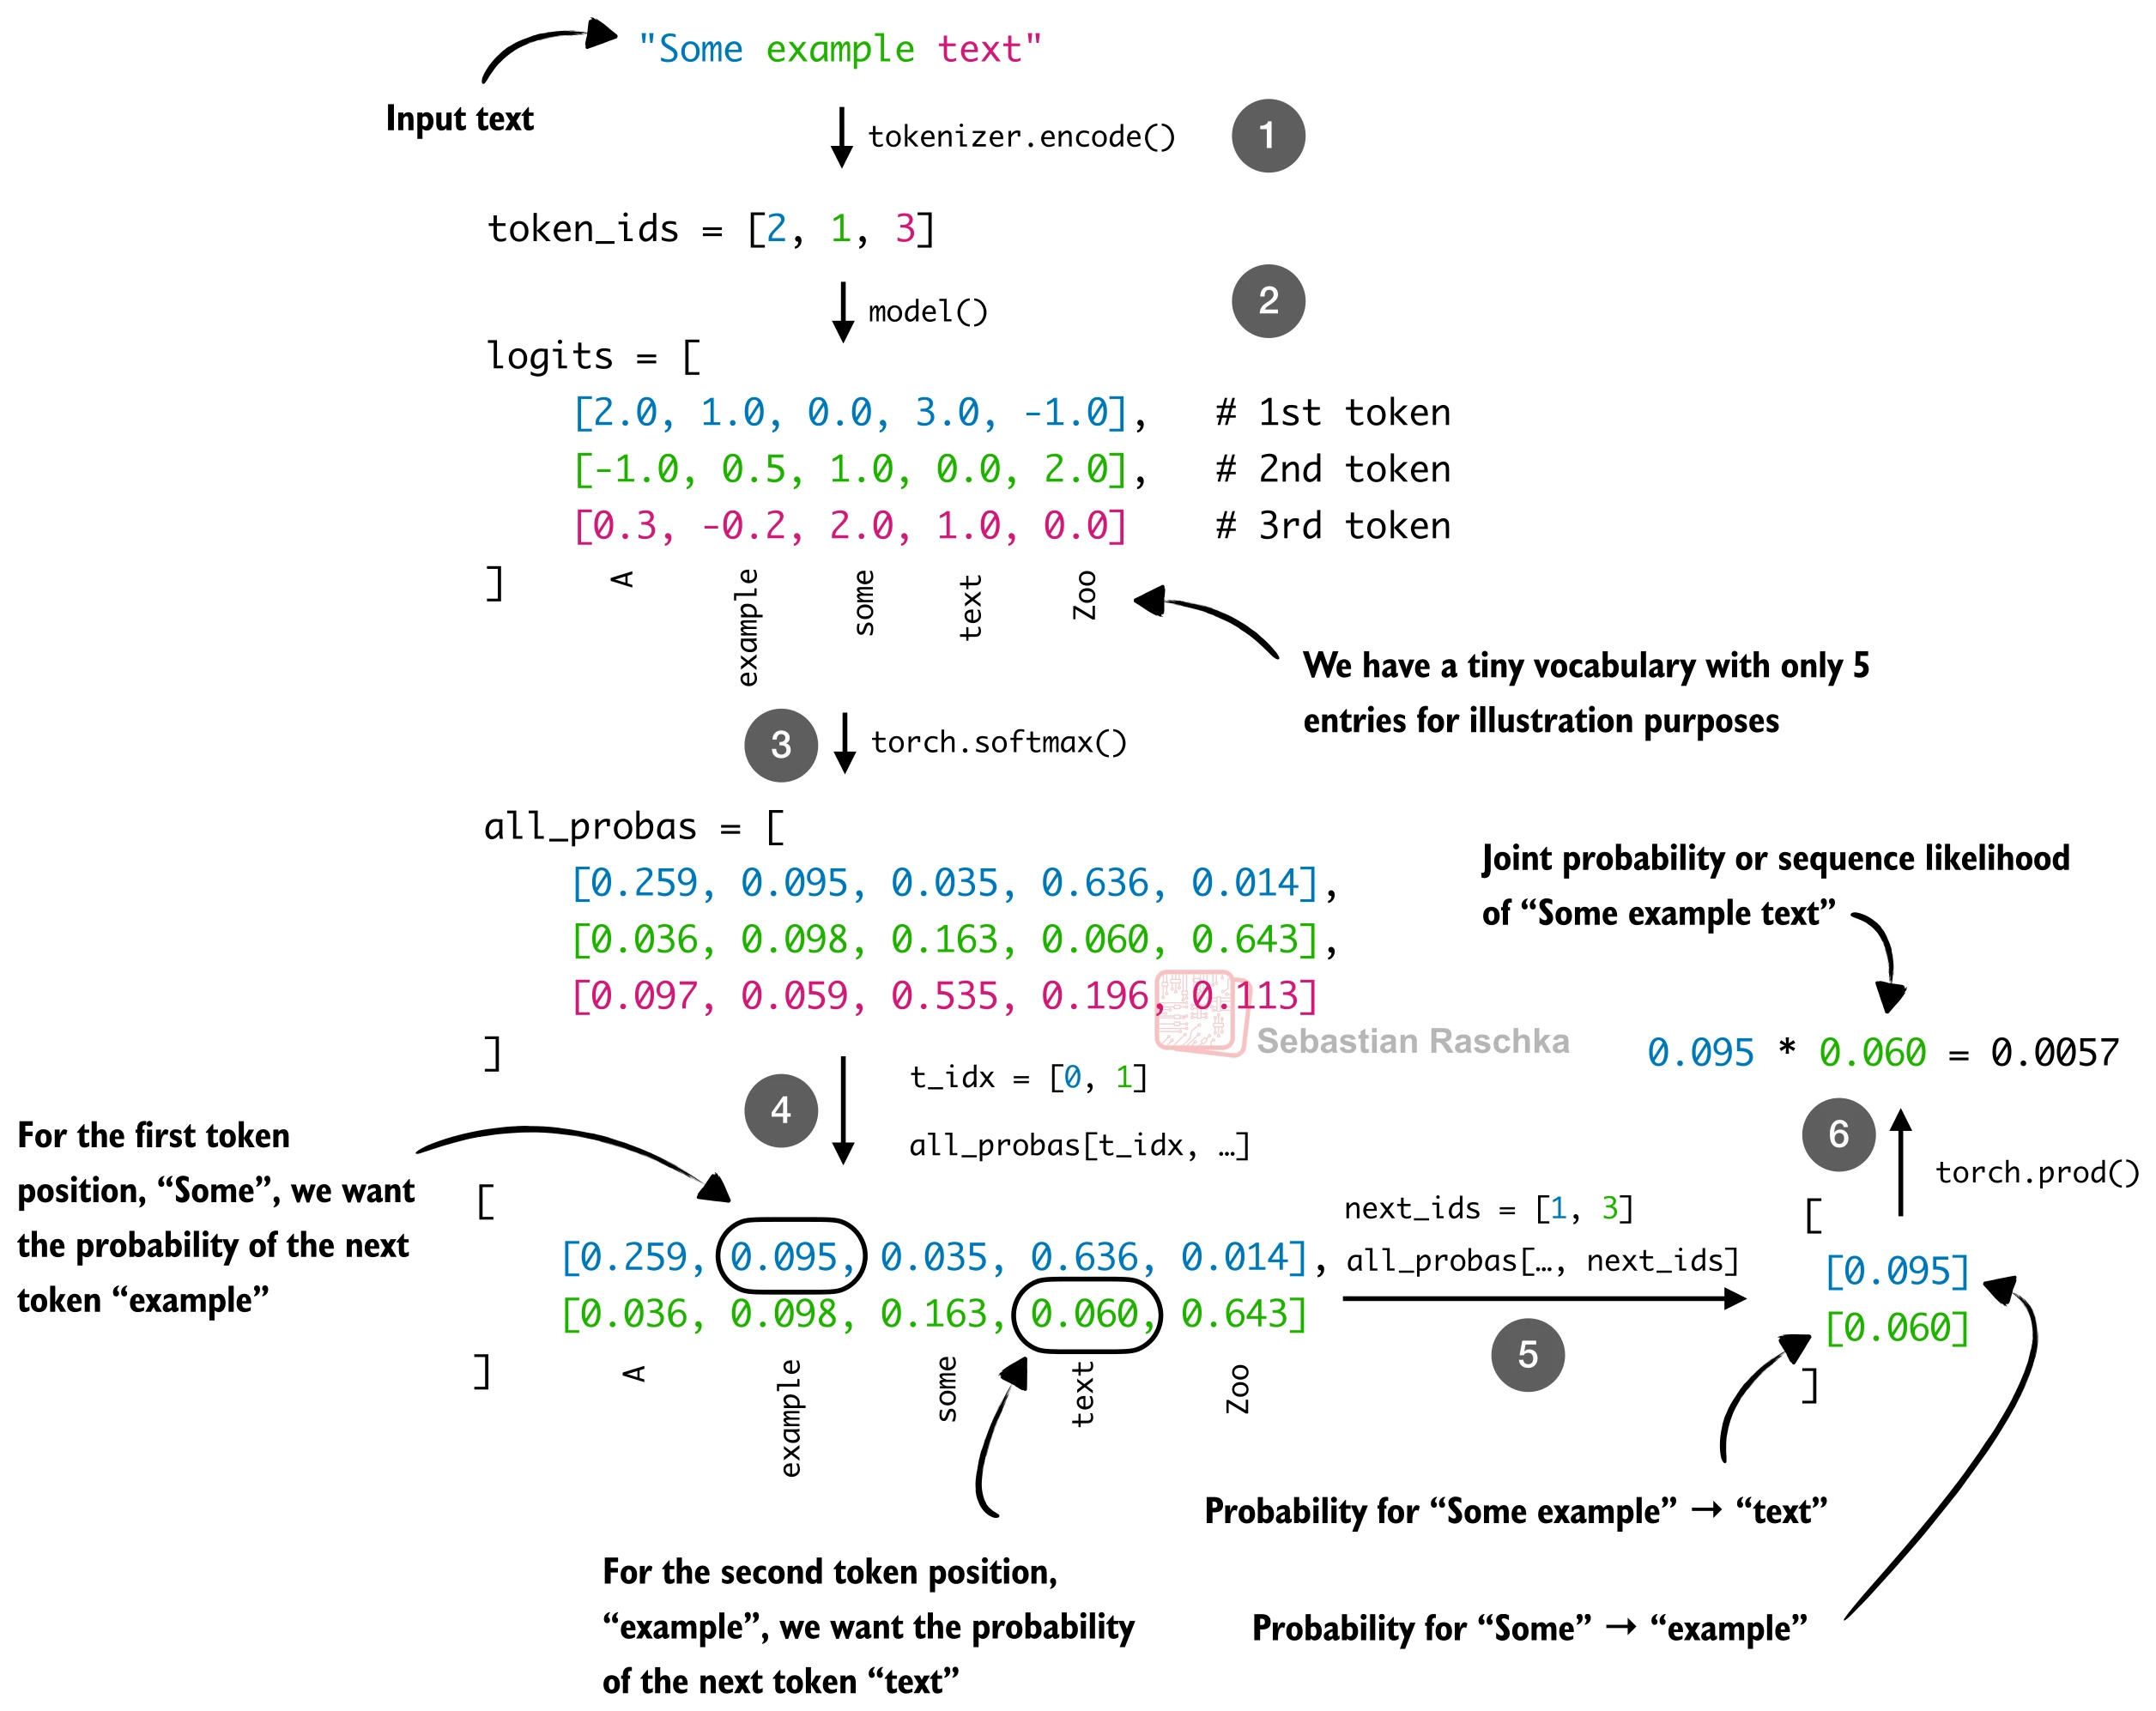

- You have a fixed sentence: t₀ t₁ t₂ ...
- For each position i, the model gives P(next token | previous tokens)
- You pick the probability of the actual next token (tᵢ₊₁)
- Multiply (or sum logs) across all positions

-  Result = how likely the model thinks this exact sentence is.

- Ignore last token because there’s no “next” token to check.

- Use log_probs since after multiplying a few probs => ~0

In [6]:
def calc_next_token_logprobs(model, tokenizer, prompt, device, show=True):
    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)
    logits = model(token_ids.unsqueeze(0)).squeeze(0)
    all_logprobs = torch.log_softmax(logits, dim=-1)

    eval_pos = torch.arange(0, token_ids.shape[0]-1, device=device) #[0,seqlen-1] no eval for last token as it predicts next unseen token
    next_ids = token_ids[1:] #targets are shifted by one
    next_token_logprobas = all_logprobs[eval_pos, next_ids] #take values from the all_logprobs table
    #eg: my name is (sanchit), P(name|my)xP(is|my name) [no last token AND targets are shifted] 

    sum_next_token_logprobas = torch.sum(next_token_logprobas)

    if show:
        print("Next-token log-probabilities:", next_token_logprobas)
        print("Joint log-probability:", sum_next_token_logprobas)
    else:
        return next_token_logprobas, sum_next_token_logprobas

In [7]:
torch.set_printoptions(precision=4, sci_mode=False)

In [8]:
calc_next_token_logprobs(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Berlin"
    )

Next-token log-probabilities: tensor([-9.7500, -0.8164, -4.1250, -0.3008, -1.8594], dtype=torch.bfloat16,
       grad_fn=<IndexBackward0>)
Joint log-probability: tensor(-16.8750, dtype=torch.bfloat16, grad_fn=<SumBackward0>)


In [9]:
calc_next_token_logprobs(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Bridge"
    )

Next-token log-probabilities: tensor([ -9.7500,  -0.8164,  -4.1250,  -0.3008, -15.0000],
       dtype=torch.bfloat16, grad_fn=<IndexBackward0>)
Joint log-probability: tensor(-30., dtype=torch.bfloat16, grad_fn=<SumBackward0>)


###  Scoring model confidence with log-probabilities

In [12]:
tokenizer.encode("hi my name is")

[6023, 847, 829, 374]

In [25]:
@torch.inference_mode()
def avg_logprob_answer(model, tokenizer, prompt, answer, device="cpu"):

    # Encode prompt and answer tokens separately to get the prompt length later
    prompt_ids = tokenizer.encode(prompt)
    answer_ids = tokenizer.encode(answer)
    full_ids = torch.tensor(prompt_ids + answer_ids, device=device)

    # Repate calc_next_token_logprobas
    logits = model(full_ids.unsqueeze(0)).squeeze(0)
    logprobs = torch.log_softmax(logits, dim=-1)

    # Index range for answer tokens (not question)
    start = len(prompt_ids) - 1
    end = full_ids.shape[0] - 1

    t_idx = torch.arange(start, end, device=device)
    next_tokens = full_ids[start + 1 : end + 1]
    next_token_logps = logprobs[t_idx, next_tokens]
    return torch.mean(next_token_logps)

In [14]:
score_1 = avg_logprob_answer(
    model, tokenizer,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Berlin.",
    device=device
)
print(score_1)

tensor(-0.1973, dtype=torch.bfloat16)


Much higher (mod) negative score expected since P(Japan | The capital of Germany is) is very very low

In [15]:
score_1 = avg_logprob_answer(
    model, tokenizer,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Japan.",
    device=device
)
print(score_1)

tensor(-3.6094, dtype=torch.bfloat16)


### Self-refinement through iterative feedback

In [21]:
def make_critique_prompt(raw_prompt, draft):
    return (
        "You are a meticulous reviewer. Identify logical errors, missing "
        "steps, or arithmetic mistakes. If the answer seems correct, "
        "say so briefly. Then propose a concise plan to fix issues.\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Draft answer:\n{draft}\n\n"
        "Write a short critique and bullet-point fix plan "
        "(under ~120 words).\n"
        "Critique:"
    )

def make_refine_prompt(raw_prompt, draft, critique):
    return (
        "Revise the answer using the critique. Keep it concise and "
        "end with a final boxed result: \\boxed{ANSWER}\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Previous answer:\n{draft}\n\n"
        f"Critique:\n{critique}\n\n"
        "Revised answer:"
    )

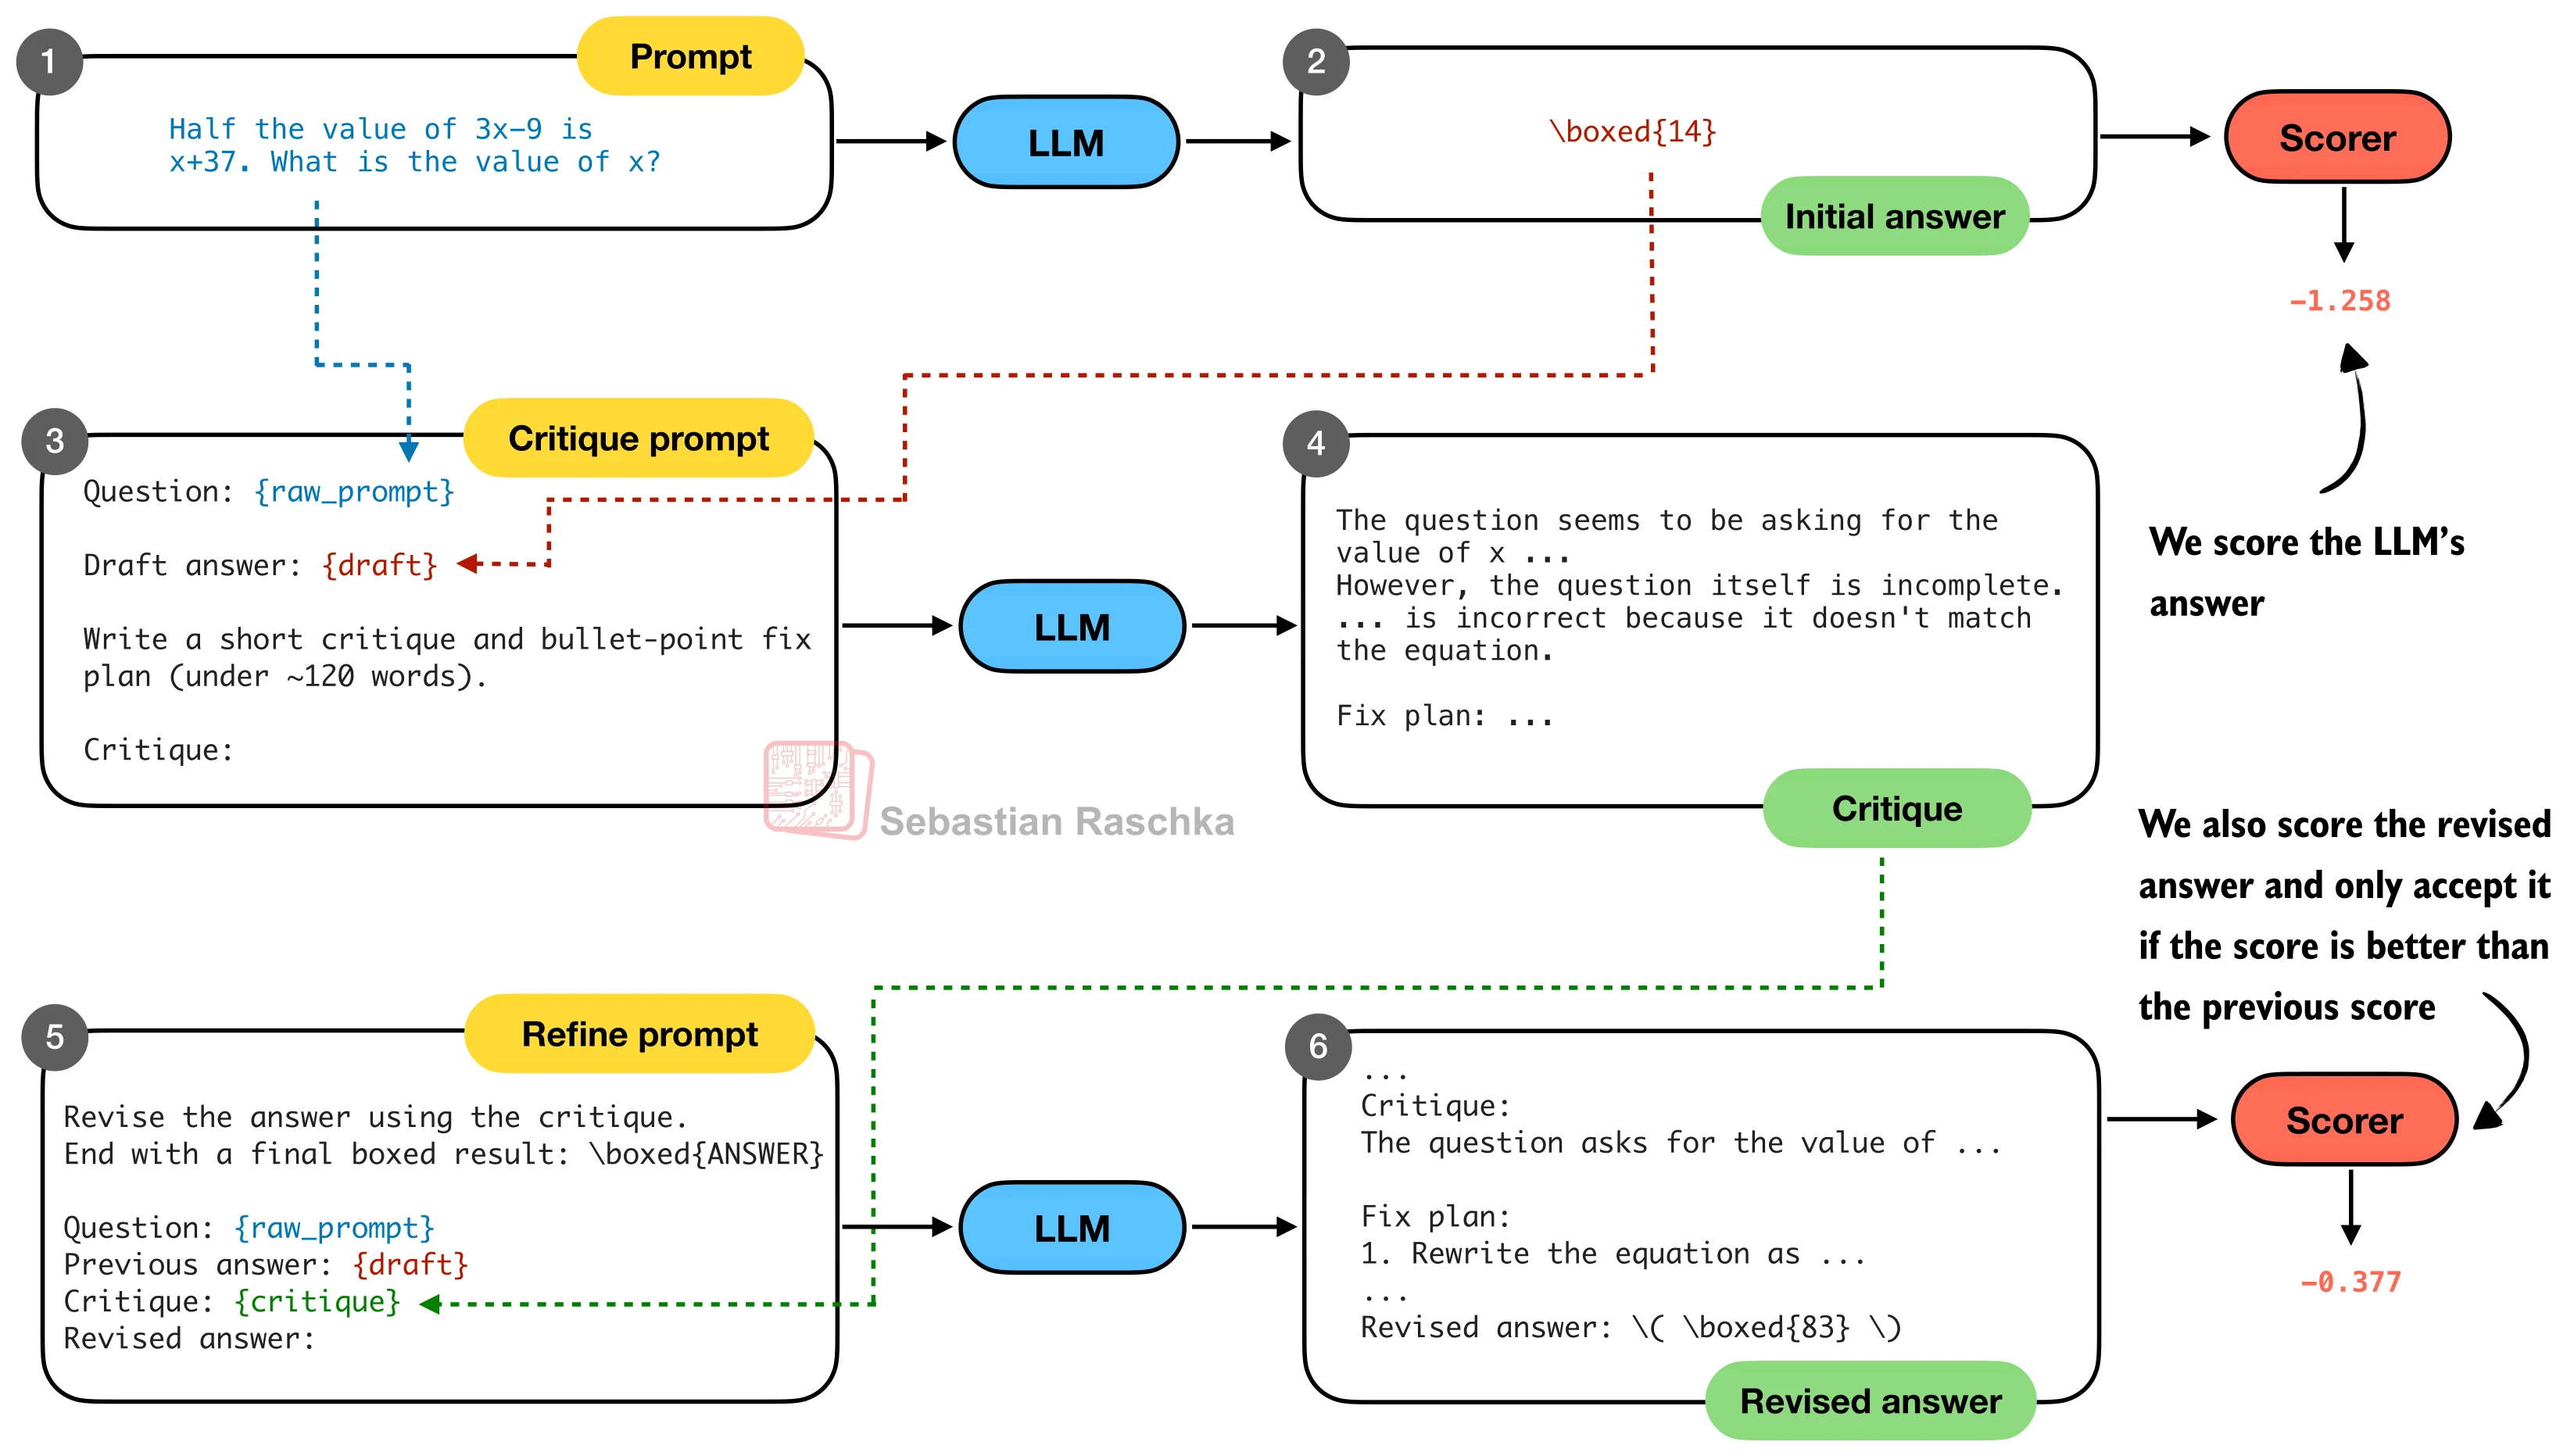

In [22]:
from reasoning_from_scratch.ch04 import generate_text_stream_concat_flex
from reasoning_from_scratch.ch04 import generate_text_top_p_stream_cache

def self_refinement_loop(
        model, tokenizer, raw_prompt, max_response_tokens = 2048, max_critique_tokens = 512,
        score_fn = None, iterations = 2, verbose = False,
        temperature = 0.7, top_p = 0.9, prompt_renderer = render_prompt, prompt_suffix = "", device = device 
):
    steps = []

    # first response (draft)
    prompt = prompt_renderer(raw_prompt) + prompt_suffix
    current_full = generate_text_stream_concat_flex(
        model=model, tokenizer=tokenizer, prompt=prompt, device=device,
        max_new_tokens=max_response_tokens, verbose=False,
        generate_func=generate_text_top_p_stream_cache, temperature=temperature, top_p=top_p
    )

    current_extracted = extract_final_candidate(current_full, fallback="number_then_full")
    if score_fn:
        current_score = score_fn(answer=current_full, prompt=prompt)
    else:
        current_score = 0.0



    for it in range(iterations):
        draft_b4_full = current_full
        draft_b4_extract = current_extracted
        score_b4 = current_score

        critique_prompt = make_critique_prompt(raw_prompt, draft_b4_extract)

        critique_full = generate_text_stream_concat_flex(
        model=model, tokenizer=tokenizer, prompt=critique_prompt, device=device,
        max_new_tokens=max_response_tokens, verbose=False,
        generate_func=generate_text_top_p_stream_cache, temperature=temperature, top_p=top_p
        )
        
        #refine
        refine_prompt = make_refine_prompt(raw_prompt, draft_b4_full, critique_full)

        revised_full = generate_text_stream_concat_flex(
        model=model, tokenizer=tokenizer, prompt=refine_prompt, device=device,
        max_new_tokens=max_response_tokens, verbose=False,
        generate_func=generate_text_top_p_stream_cache, temperature=temperature, top_p=top_p
        )

        revised_extracted = extract_final_candidate(
            revised_full, fallback="number_then_full"
        )
        if score_fn:
            revised_score = score_fn(answer=revised_full, prompt=prompt)  #use original prompt only
        else:
            revised_score = 0.0
        
        # Log the results
        step = {
            "iteration": it + 1,
            "draft_full": draft_b4_full,
            "draft_extracted": draft_b4_extract,
            "critique": critique_full,
            "revised_full": revised_full,
            "revised_extracted": revised_extracted,
            "score_before": score_b4,
            "score_after": revised_score,
        }
        steps.append(step)

        if verbose:
            print(
                f"[Refinement {it+1}/{iterations}]"
                f"\nCurrent: {draft_b4_extract}"
                f"\nRevised: {revised_extracted}"
                f"\nScore before: {score_b4:.3f}"
                f"\nScore after: {revised_score:.3f}"
                f"\n{'=' * 25}"
            )

        # Accept revised response if it's not worse
        if revised_score >= current_score:
            current_full = revised_full
            current_extracted = revised_extracted
            current_score = revised_score

    return {
        "final_full": current_full,
        "final_extracted": current_extracted,
        "steps": steps,
    }

In [26]:
from functools import partial

avg_logprob_score = partial(
    avg_logprob_answer,
    model=model,
    tokenizer=tokenizer,
    device=device
)

In [27]:
torch.manual_seed(42)

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)

results_logprob = self_refinement_loop(
    model=model,
    tokenizer=tokenizer,
    raw_prompt=raw_prompt,
    device=device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=avg_logprob_score,
    verbose=True,
    temperature=0.7,
    top_p=0.9,
)

[Refinement 1/2]
Current: x=40
Revised: x=40
Score before: -1.164
Score after: -1.164
[Refinement 2/2]
Current: x=40
Revised: x=83
Score before: -1.164
Score after: -2.688
